# Оптимизация логистической сети Pirelli Tyre

**Проект по курсу «Экономико-математические методы в логистике»**


> Состав команды:
Гелашвили Анна,
Кукачев Ян,
Морозова Полина,
Никитина Кира,
Ситнова Анастасия


Цель модели — определить оптимальную конфигурацию логистической сети:
- какие склады открыть;
- как распределить потоки от заводов к складам;
- как распределить потоки от складов к городам спроса;
- как изменяется решение при разных требованиях к SLA, спросу и арендным ставкам.

## Схема логистической сети

На схеме представлена первоначальная структура сети Pirelli Tyre: заводы (plants), региональные распределительные центры (warehouses) и города спроса (delivery points). Эта схема легла в основу математической модели.
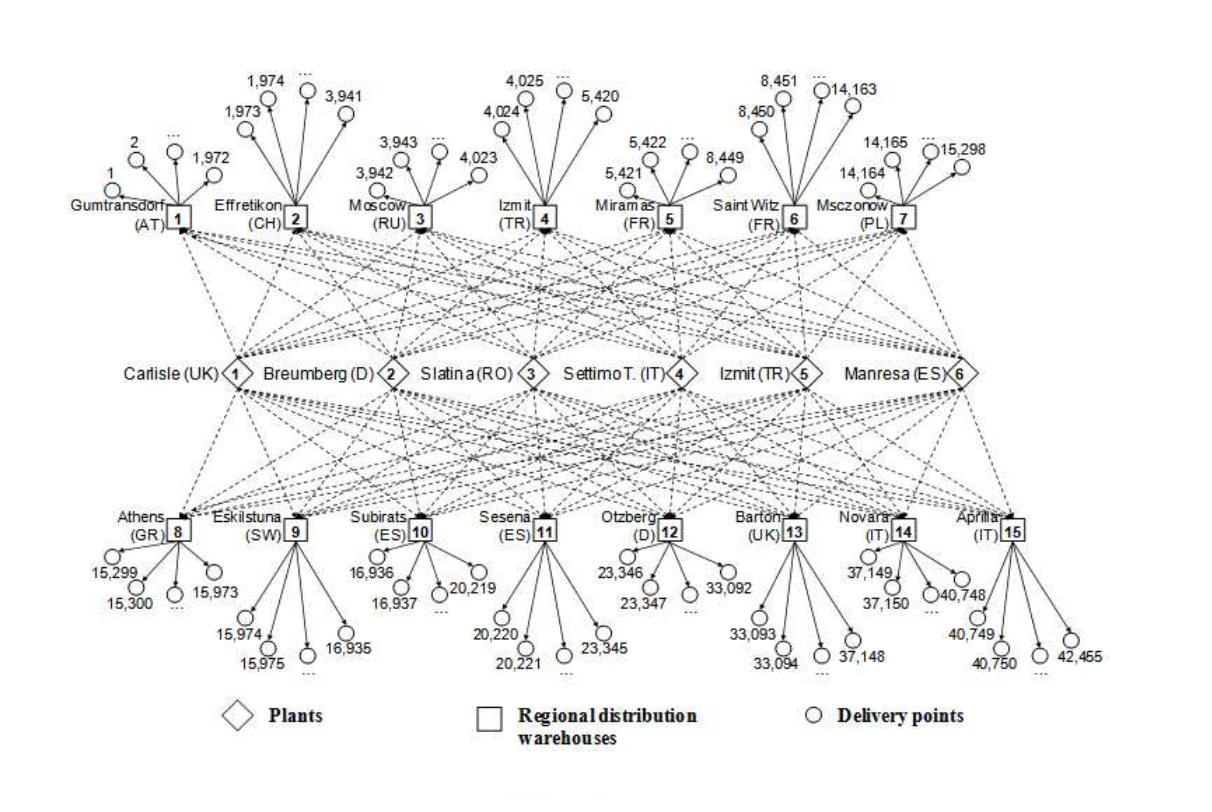


*Источник: Applying-an-integrated-logistics-network-design-and-optimisation-model-the-Pirelli-Tyre-Case*

## Математическая постановка задачи

**Множества**

- $P$ - множество заводов
- $W$ - множество складов
- $C$ - множество городов/агрегированных точек спроса
- $S$ - множество сценариев

**Индексы:**

- $p$ - индекс завода, $p \in P$;
- $w$ - индекс потенциального регионального склада, $w \in W$;
- $c$ - индекс города / агрегированной точки спроса, $c \in C$;
- $s$ - индекс сценария, $s \in S$.

**Параметры**

- $lat^P_p$ - **lat_plant**; широта завода
- $lon^P_p$ - **lon_plant**; долгота завода
- $lat^W_w$ - **lat**; широта склада
- $lon^W_w$ - **lon**; долгота склада
- $lat^C_c$ - **lat_city**; широта города
- $lon^C_c$ - **lon_city**; долгота города

- $D^0_c$ - **demand_t**; базовый годовой спрос города в тоннах
- $\alpha$ - **demand_factor**; сценарный коэффициент изменения спроса
- $D_c$ - **demand**; спрос города в кг

- $cap_w$ - **capacity_tonnes**; годовая мощность склада в тоннах
- $rent_w$ - **rent_eur_m2**; стоимость аренды складской площади, евро/м²
- $h_w$ - **handling_eur_kg**; стоимость обработки 1 кг продукции на складе
- $itr_w$ - **itr**; коэффициент оборачиваемости запасов на складе
- $f_w$ - **fixed_cost**; фиксированные затраты на открытие склада
- $\beta$ - **fixed_multiplier**; сценарный коэффициент изменения арендной ставки
- $rent'_w$ - **rent_adj**; скорректированная арендная ставка склада

- $q$ - **ftl_capacity**; вместимость полной грузовой отправки
- $cost^{FTL}_{pw}$ - **cost_ftl_abs**; стоимость полной отправки от завода до склада
- $cp_{pw}$ - **cp**; стоимость перевозки 1 тонны от завода до склада

- $v$ - **avg_speed**; средняя скорость транспортировки
- $H$ - **hours**; максимально допустимое время доставки
- $\gamma$ - **circuity**; коэффициент кривизны маршрута
- $R$ - **R**; радиус Земли
- $dist_{wc}$ - **dist**; скорректированное расстояние от склада до города
- $cs_{wc}$ - **cs**; стоимость вторичной перевозки 1 кг от склада до города
- $SL$ - **sl_tariff**; минимальный тариф на доставку
- $\rho$ - **S_density**; показатель плотности хранения / использования складской площади

**Переменные**

- $o_w$ - **Open**; бинарная переменная открытия склада: 1 - склад открыт, 0 - склад закрыт
- $a_{wc}$ - **Assign**; бинарная переменная назначения города складу: 1 - город обслуживается складом, 0 - нет
- $y_{wc}$ - **Flow**; поток продукции от склада $w$ в город $c$, кг/год
- $x_{pw}$ - **FlowPW**; поток продукции от завода $p$ на склад $w$, кг/год

**Ограничения**

- Спрос каждого города должен быть удовлетворён:

$$
\sum_{w \in W} y_{wc} \geq D_c, \quad \forall c \in C
$$

- Входящий поток на склад должен быть равен суммарным отгрузкам со склада в города:

$$
\sum_{p \in P} x_{pw} = \sum_{c \in C} y_{wc}, \quad \forall w \in W
$$

- Каждый город должен быть назначен как минимум одному складу:

$$
\sum_{w \in W} a_{wc} \geq 1, \quad \forall c \in C
$$

- Поток от склада к городу возможен только в том случае, если город назначен этому складу:

$$
y_{wc} \leq D_c \cdot a_{wc}, \quad \forall w \in W, c \in C
$$

- Поток через склад не должен превышать его годовую мощность. Если склад закрыт, поток через него невозможен:

$$
\sum_{c \in C} y_{wc} \leq сap_w \cdot o_w \cdot 1000, \quad \forall w \in W
$$

- Город может быть назначен складу только в том случае, если доставка укладывается в допустимое сервисное окно:

$$
a_{wc} \leq
\begin{cases}
1, & \text{если } dist_{wc} \leq H \cdot v \\
0, & \text{если } dist_{wc} > H \cdot v
\end{cases},
\quad \forall w \in W, c \in C
$$

- Город может быть назначен только открытому складу:

$$
a_{wc} \leq o_w, \quad \forall w \in W, c \in C
$$

- Если склад открыт, через него должен проходить положительный поток:

$$
\sum_{c \in C} y_{wc} \geq o_w, \quad \forall w \in W
$$


**Целевая функция**

$$
\sum_{p \in P, w \in W} cp_{pw} \cdot \frac{x_{pw}}{1000}
+
\sum_{w \in W, c \in C} cs_{wc} \cdot y_{wc}
+
\sum_{w \in W} rent'_{w} \cdot \frac{\sum_{c \in C} y_{wc}}{itr_w \cdot \rho}
+
\sum_{w \in W, c \in C} h_w \cdot y_{wc}
+
\sum_{w \in W} f_w \cdot o_w
\to \min
$$

# **Базовая модель**

## 1. Установка и настройка среды

In [1]:
%pip install -q amplpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 42.2 MB/s eta 0:00:00


Подключаем AMPL с расширениями для работы с решателем HiGHS и чтением Excel-файлов.

In [2]:
from amplpy import AMPL, ampl_notebook

ampl = ampl_notebook(
    modules=["highs", "plugins"],  # highs + amplxl для Excel
    license_uuid="default",
)

Using default Community Edition License for Colab. Get yours at: https://ampl.com/ce
Licensed to AMPL Community Edition License for the AMPL Model Colaboratory (https://ampl.com/colab).


## 2. Загрузка исходных данных

Данные хранятся в Excel-файле `dataset_pirelli_.xlsx`.
Он содержит:
- Координаты заводов, складов и городов
- Спрос, тарифы, параметры складов (аренда, обработка, мощность)
- Набор сценариев для анализа чувствительности


In [3]:
!wget https://github.com/polina-jpg/pirelli_rs/raw/refs/heads/main/data/dataset_pirelli_.xlsx

--2026-06-27 20:04:34--  https://github.com/polina-jpg/pirelli_rs/raw/refs/heads/main/data/dataset_pirelli_.xlsx
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/polina-jpg/pirelli_rs/refs/heads/main/data/dataset_pirelli_.xlsx [following]
--2026-06-27 20:04:34--  https://raw.githubusercontent.com/polina-jpg/pirelli_rs/refs/heads/main/data/dataset_pirelli_.xlsx
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 46618 (46K) [application/octet-stream]
Saving to: ‘dataset_pirelli_.xlsx’

dataset_pirelli_.xl 100%[===================>]  45.53K  --.-KB/s    in 0.006s  

2026-06-27 20:04:34 (7.37 MB/s) - ‘d

## 3. Объявление математической модели в AMPL

В этом разделе задается общая структура MILP-модели: множества, параметры,переменные, ограничения и целевая функция.

In [4]:
%%ampl_eval
reset;


# МНОЖЕСТВА

set P; # заводы Pirelli, являющиеся источниками продукции
set W; # потенциальные распределительные склады
set C; # города (агрегированные точки спроса)
set S; # набор сценариев для анализа чувствительности модели



# ПАРАМЕТРЫ

# координаты заводов
param lat_plant{P};
param lon_plant{P};

# координаты складов
param lat{W};
param lon{W};

# параметры складов
param rent_eur_m2{W};     # стоимость аренды 1 м² склада
param handling_eur_kg{W}; # стоимость обработки 1 кг продукции
param capacity_tonnes{W}; # максимальная годовая мощность склада
param itr{W};             # коэффициент оборачиваемости запасов
param fixed_cost{W};      # фиксированные расходы на открытие склада

# координаты и спрос городов
param lat_city{C};
param lon_city{C};
param demand_t{C};

# тарифы завод -> склад
param cost_ftl_abs{P, W};

# глобальные параметры
param circuity;                 # извилистость дорог
param avg_speed;                # средняя скорость доставки
param max_km;                   # максимальная допустимая дальность
param ftl_capacity;             # грузоподъемность полной машины
param S_density;                # норматив плотности хранения
param sl_tariff;                # минимальный тариф последней мили
param hours default 36;         # целевой SLA по времени доставки
param demand_factor default 1;  # множитель спроса для сценариев
param fixed_multiplier default 1; # множитель арендных затрат для сценариев

# параметры для выполнения сценариев
param scenario_group{S} symbolic;
param scenario_order{S} default 0;
param scenario_hours{S} default 36;
param scenario_demand_factor{S} default 1;
param scenario_rent_multiplier{S} default 1;
param scenario_active{S} default 1;



# РАСЧЕТНЫЕ ПАРАМЕТРЫ

# перевод спроса из тонн в килограммы
param demand{c in C} = demand_t[c] * 1000 * demand_factor;

# стоимость перевозки 1 тонны продукции с завода на склад
param cp{p in P, w in W} = cost_ftl_abs[p,w] / ftl_capacity;

# корректировка арендной ставки в рамках сценарного анализа
param rent_adj{w in W} = rent_eur_m2[w] * fixed_multiplier;

# расчет расстояния склад -> город по гаверсинусу
param pi := 3.14159265358979;
param R := 6371;

param dlat{w in W, c in C} = (lat[w] - lat_city[c]) * pi / 180;
param dlon{w in W, c in C} = (lon[w] - lon_city[c]) * pi / 180;
param a{w in W, c in C} =
    sin(dlat[w,c]/2)^2 +
    cos(lat[w]*pi/180) * cos(lat_city[c]*pi/180) * sin(dlon[w,c]/2)^2;
param dist{w in W, c in C} =
    circuity * 2 * R * asin(sqrt(a[w,c]));

# стоимость вторичной перевозки
# используется эмпирическая зависимость стоимости от расстояния доставки
param cs{w in W, c in C} = max(0.1139 * (dist[w,c] ^ 0.157), sl_tariff / ftl_capacity);



# ПЕРЕМЕННЫЕ РЕШЕНИЯ

var Assign{W, C} binary;  # показывает обслуживает ли склад W город C

var Open{W} binary;       # показывает открыт ли склад W

var Flow{W, C} >= 0;      # годовой поток склад -> город (кг/год)

var FlowPW{P, W} >= 0;    # годовой поток завод -> склад (кг/год)



# ЦЕЛЕВАЯ ФУНКЦИЯ

minimize TotalCost:

    # стоимость доставки продукции с заводов на склады
    sum{p in P, w in W} cp[p,w] * FlowPW[p,w] / 1000

    # стоимость доставки продукции со складов в города
  + sum{w in W, c in C} cs[w,c] * Flow[w,c]

    # аренда складских площадей
  + sum{w in W} rent_adj[w] * (sum{c in C} Flow[w,c] / (itr[w] * S_density))

    # стоимость складской обработки продукции
  + sum{w in W, c in C} handling_eur_kg[w] * Flow[w,c]

    # фиксированные затраты на содержание
  + sum{w in W} fixed_cost[w] * Open[w];



# ОГРАНИЧЕНИЯ

# Выполнение спроса
# каждый город должен получить не меньше требуемого объёма продукции независимо от выбранной конфигурации сети

subject to DemandFulfillment{c in C}:
    sum{w in W} Flow[w,c] >= demand[c];

# Баланс потоков на склад
# склад не может отгрузить больше продукции, чем получил от заводов

subject to WarehouseBalance{w in W}:
    sum{p in P} FlowPW[p,w] =
    sum{c in C} Flow[w,c];

# Каждый город должен быть закреплён минимум за одним складом

subject to AtLeastOneWarehousePerCity{c in C}:
    sum{w in W} Assign[w,c] >= 1;

# Поток возможен только между связанными объектами

subject to FlowOnlyIfAssigned{w in W, c in C}:
    Flow[w,c] <= demand[c] * Assign[w,c];

# Ограничение мощности склада
# суммарный объём продукции, проходящий через склад, не может превышать его проектную пропускную способность

subject to CapacityLimit{w in W}:
    sum{c in C} Flow[w,c] <= capacity_tonnes[w] * Open[w] * 1000;

# Ограничение по SLA
# город может быть закреплён за складом только тогда, когда расчётное время доставки укладывается в допустимый сервисный уровень

subject to ServiceAvailability{w in W, c in C}:
    Assign[w,c] <= if dist[w,c] <= (hours * avg_speed) then 1 else 0;

# Использовать для обслуживания можно только открытые склады

subject to OpenIfUsed{w in W, c in C}:
    Assign[w,c] <= Open[w];

# Если склад открыт, через него должен проходить хотя бы некоторый объём продукции

subject to WarehouseMustBeUsed{w in W}:
    sum{c in C} Flow[w,c] >= Open[w];



# ЗАГРУЗКА ДАННЫХ ИЗ ЭКСЕЛЬ

table params_table IN "amplxl" "dataset_pirelli_.xlsx" "param":
    [], circuity, avg_speed, max_km, ftl_capacity, S_density, sl_tariff;

table P_table IN "amplxl" "dataset_pirelli_.xlsx" "plants":
    P <- [id],
    lat_plant ~ lat,
    lon_plant ~ lon;

table W_table IN "amplxl" "dataset_pirelli_.xlsx" "warehouses":
    W <- [id],
    lat,
    lon,
    rent_eur_m2,
    handling_eur_kg,
    capacity_tonnes,
    itr,
    fixed_cost;

table C_table IN "amplxl" "dataset_pirelli_.xlsx" "cities":
    C <- [id],
    lat_city,
    lon_city,
    demand_t;

table tariffs_table IN "amplxl" "dataset_pirelli_.xlsx" "tariffs_primary":
    [plant_id, wh_id], cost_ftl_abs;


table scenarios_table IN "amplxl" "dataset_pirelli_.xlsx" "scenarios":
    S <- [scenario_id],
    scenario_group,
    scenario_order,
    scenario_hours ~ hours,
    scenario_demand_factor ~ demand_factor,
    scenario_rent_multiplier ~ rent_multiplier,
    scenario_active ~ active;

load amplxl.dll;
read table params_table;
read table P_table;
read table W_table;
read table C_table;
read table tariffs_table;
read table scenarios_table;

## 4. Базовый сценарий

В базовом сценарии используются исходные значения:
- SLA = 36 часов;
- коэффициент спроса = 1;
- множитель аренды = 1.

Цель раздела — получить основную конфигурацию сети и ключевые показатели решения.

In [5]:
%%ampl_eval
option solver highs;
option solver_msg 0;
option highs_options "time_limit=300 mip_rel_gap=0.01"; # максимальное время поиска решения 5 минут и допустимое отклонение от оптимума - 1%

# берем параметры базового сценария из строки scenario_id = "base"
let hours := scenario_hours["base"];
let demand_factor := scenario_demand_factor["base"];
let fixed_multiplier := scenario_rent_multiplier["base"];

solve; # запуск оптимизации

# вывод результатов
printf "\n=== BASE SCENARIO ===\n";
printf "Scenario ID: base\n";
printf "Hours: %.0f\n", hours;
printf "Demand factor: %.2f\n", demand_factor;
printf "Rent multiplier: %.2f\n", fixed_multiplier;
printf "Status: %s\n", solve_result;
printf "TOTAL COST: %.0f\n", TotalCost;
printf "OPEN WAREHOUSES: %d\n", sum {w in W} Open[w];
printf "TOTAL DEMAND, tonnes: %.2f\n", sum {c in C} demand[c] / 1000;

HiGHS 1.14.0:   lim:time = 300
  mip:gap = 0.01

=== BASE SCENARIO ===
Scenario ID: base
Hours: 36
Demand factor: 1.00
Rent multiplier: 1.00
Status: solved
TOTAL COST: 214928339
OPEN WAREHOUSES: 17
TOTAL DEMAND, tonnes: 657153.20


### Экспорт данных для визуализации
Сохраняем узлы (заводы, открытые склады, города) и дуги (потоки) в CSV-файлы для построения интерактивной карты.

In [6]:
%%ampl_eval

printf "\n=== EXPORT MAP DATA FROM CURRENT SOLUTION ===\n";

# Узлы сети: заводы, открытые склады, города

printf "id,type,lat,lon,value_t\n" > "map_nodes.csv";

# Заводы
for {p in P} {
    printf "%s,plant,%.6f,%.6f,0\n",
        p,
        lat_plant[p],
        lon_plant[p]
        >> "map_nodes.csv";
}

# Только открытые склады
for {w in W: Open[w] > 0.5} {
    printf "%s,warehouse,%.6f,%.6f,%.3f\n",
        w,
        lat[w],
        lon[w],
        sum {c in C} Flow[w,c] / 1000
        >> "map_nodes.csv";
}

# Города / точки спроса
for {c in C} {
    printf "%s,city,%.6f,%.6f,%.3f\n",
        c,
        lat_city[c],
        lon_city[c],
        demand[c] / 1000
        >> "map_nodes.csv";
}


# Дуги сети: завод -> склад и склад -> город

printf "from_id,to_id,arc_type,from_lat,from_lon,to_lat,to_lon,flow_t,time_h\n" > "map_arcs.csv";

# Потоки завод -> склад
for {p in P, w in W: FlowPW[p,w] > 0.000001} {
    printf "%s,%s,plant_to_warehouse,%.6f,%.6f,%.6f,%.6f,%.3f,\n",
        p,
        w,
        lat_plant[p],
        lon_plant[p],
        lat[w],
        lon[w],
        FlowPW[p,w] / 1000
        >> "map_arcs.csv";
}

# Потоки склад -> город
for {w in W, c in C: Flow[w,c] > 0.000001} {
    printf "%s,%s,warehouse_to_city,%.6f,%.6f,%.6f,%.6f,%.3f,%.3f\n",
        w,
        c,
        lat[w],
        lon[w],
        lat_city[c],
        lon_city[c],
        Flow[w,c] / 1000,
        dist[w,c] / avg_speed
        >> "map_arcs.csv";
}

printf "Map data saved: map_nodes.csv, map_arcs.csv\n";


=== EXPORT MAP DATA FROM CURRENT SOLUTION ===
Map data saved: map_nodes.csv, map_arcs.csv


### Визуализация сети на карте
Используем библиотеку Folium для построения интерактивной карты с наложением потоков. Размер узлов пропорционален объёму, толщина дуг — интенсивности потока.

In [7]:

!pip install -q folium

import os
import math
import pandas as pd
import folium
from IPython.display import display

nodes_path = "map_nodes.csv"
arcs_path = "map_arcs.csv"

if not os.path.exists(nodes_path):
    raise FileNotFoundError("Файл map_nodes.csv не найден. Сначала запусти AMPL-блок экспорта карты.")

if not os.path.exists(arcs_path):
    raise FileNotFoundError("Файл map_arcs.csv не найден. Сначала запусти AMPL-блок экспорта карты.")

nodes = pd.read_csv(nodes_path)
arcs = pd.read_csv(arcs_path)

# Приводим идентификаторы к строкам
nodes["id"] = nodes["id"].astype(str)
arcs["from_id"] = arcs["from_id"].astype(str)
arcs["to_id"] = arcs["to_id"].astype(str)

# Приводим числовые поля
for col in ["lat", "lon", "value_t"]:
    nodes[col] = pd.to_numeric(nodes[col], errors="coerce")

for col in ["from_lat", "from_lon", "to_lat", "to_lon", "flow_t", "time_h"]:
    arcs[col] = pd.to_numeric(arcs[col], errors="coerce")

# Убираем строки с пустыми координатами
nodes = nodes.dropna(subset=["lat", "lon"]).copy()
arcs = arcs.dropna(subset=["from_lat", "from_lon", "to_lat", "to_lon"]).copy()

display(nodes.head())
display(arcs.head())


# Подготовка данных для подсказок

plant_out = (
    arcs[arcs["arc_type"] == "plant_to_warehouse"]
    .groupby("from_id")["flow_t"]
    .sum()
    .to_dict()
)

warehouse_in = (
    arcs[arcs["arc_type"] == "plant_to_warehouse"]
    .groupby("to_id")["flow_t"]
    .sum()
    .to_dict()
)

warehouse_out = (
    arcs[arcs["arc_type"] == "warehouse_to_city"]
    .groupby("from_id")["flow_t"]
    .sum()
    .to_dict()
)

city_in = (
    arcs[arcs["arc_type"] == "warehouse_to_city"]
    .groupby("to_id")["flow_t"]
    .sum()
    .to_dict()
)

def fmt_num(x, decimals=0):
    if pd.isna(x):
        return "-"
    return f"{x:,.{decimals}f}".replace(",", " ")


# Настройки отображения

# Чтобы карта не была перегружена, показываем только крупнейшие потоки склад -> город
TOP_SECONDARY_FLOWS = 150

primary_arcs = arcs[arcs["arc_type"] == "plant_to_warehouse"].copy()
secondary_arcs = arcs[arcs["arc_type"] == "warehouse_to_city"].copy()

secondary_arcs = secondary_arcs.nlargest(TOP_SECONDARY_FLOWS, "flow_t")

map_arcs = pd.concat([primary_arcs, secondary_arcs], ignore_index=True)

center_lat = nodes["lat"].mean()
center_lon = nodes["lon"].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=4,
    tiles="CartoDB positron"
)

plants_layer = folium.FeatureGroup(name="Заводы", show=True)
warehouses_layer = folium.FeatureGroup(name="Открытые склады", show=True)
cities_layer = folium.FeatureGroup(name="Города спроса", show=True)
primary_layer = folium.FeatureGroup(name="Потоки завод → склад", show=True)
secondary_layer = folium.FeatureGroup(name="Потоки склад → город", show=True)


# Узлы: заводы, склады, города

for _, row in nodes.iterrows():

    if row["type"] == "plant":
        out_flow = plant_out.get(row["id"], 0)

        tooltip_text = (
            f"<b>Завод {row['id']}</b><br>"
            f"Отгружено: <b>{fmt_num(out_flow)} т</b>"
        )

        folium.CircleMarker(
            location=[row["lat"], row["lon"]],
            radius=7,
            color="black",
            fill=True,
            fill_color="black",
            fill_opacity=0.9,
            popup=tooltip_text,
            tooltip=folium.Tooltip(tooltip_text)
        ).add_to(plants_layer)

    elif row["type"] == "warehouse":
        flow_in = warehouse_in.get(row["id"], 0)
        flow_out = warehouse_out.get(row["id"], 0)

        radius = max(6, min(16, 6 + math.sqrt(max(flow_out, 0)) / 80))

        tooltip_text = (
            f"<b>Склад {row['id']}</b><br>"
            f"Получено с заводов: <b>{fmt_num(flow_in)} т</b><br>"
            f"Отгружено в города: <b>{fmt_num(flow_out)} т</b>"
        )

        folium.CircleMarker(
            location=[row["lat"], row["lon"]],
            radius=radius,
            color="blue",
            fill=True,
            fill_color="blue",
            fill_opacity=0.75,
            popup=tooltip_text,
            tooltip=folium.Tooltip(tooltip_text)
        ).add_to(warehouses_layer)

    elif row["type"] == "city":
        demand = row["value_t"]
        received = city_in.get(row["id"], 0)
        service_level = 100 * received / demand if demand > 0 else 0

        radius = max(3, min(10, 3 + math.sqrt(max(demand, 0)) / 80))

        tooltip_text = (
            f"<b>Город {row['id']}</b><br>"
            f"Спрос: <b>{fmt_num(demand)} т</b><br>"
            f"Получено: <b>{fmt_num(received)} т</b><br>"
            f"Покрытие: <b>{service_level:.1f}%</b>"
        )

        folium.CircleMarker(
            location=[row["lat"], row["lon"]],
            radius=radius,
            color="gray",
            fill=True,
            fill_color="gray",
            fill_opacity=0.45,
            popup=tooltip_text,
            tooltip=folium.Tooltip(tooltip_text)
        ).add_to(cities_layer)


# Дуги: завод -> склад и склад -> город

max_flow = map_arcs["flow_t"].max() if not map_arcs.empty else 1

def line_weight(flow):
    if pd.isna(flow) or max_flow <= 0:
        return 1
    return max(1, min(8, 1 + 7 * math.sqrt(flow / max_flow)))

for _, row in map_arcs.iterrows():

    if row["arc_type"] == "plant_to_warehouse":
        layer = primary_layer
        color = "purple"
        arc_name = "Завод → склад"
        time_text = ""

    else:
        layer = secondary_layer
        color = "green"
        arc_name = "Склад → город"
        time_text = (
            f"<br>Время доставки: <b>{row['time_h']:.1f} ч</b>"
            if not pd.isna(row["time_h"])
            else ""
        )

    tooltip_text = (
        f"<b>{row['from_id']} → {row['to_id']}</b><br>"
        f"Тип: <b>{arc_name}</b><br>"
        f"Объём: <b>{fmt_num(row['flow_t'])} т</b>"
        f"{time_text}"
    )

    folium.PolyLine(
        locations=[
            [row["from_lat"], row["from_lon"]],
            [row["to_lat"], row["to_lon"]]
        ],
        weight=line_weight(row["flow_t"]),
        color=color,
        opacity=0.45,
        popup=tooltip_text,
        tooltip=folium.Tooltip(tooltip_text)
    ).add_to(layer)


# Добавление слоев

primary_layer.add_to(m)
secondary_layer.add_to(m)
plants_layer.add_to(m)
warehouses_layer.add_to(m)
cities_layer.add_to(m)


# Простая легенда / плашка карты

open_count = nodes[nodes["type"] == "warehouse"]["id"].nunique()
plant_count = nodes[nodes["type"] == "plant"]["id"].nunique()
city_count = nodes[nodes["type"] == "city"]["id"].nunique()
total_demand_t = nodes.loc[nodes["type"] == "city", "value_t"].sum()

legend_html = f"""
<div style="
    position: fixed; bottom: 36px; left: 36px; z-index: 9999;
    background: white; padding: 12px 16px; border-radius: 8px;
    border: 1px solid #bbb; box-shadow: 2px 2px 8px rgba(0,0,0,0.18);
    font-family: Arial, sans-serif; font-size: 13px; line-height: 1.8;
    min-width: 220px;
">
    <b style="font-size:14px">Pirelli network</b><br>
    Заводов: <b>{plant_count}</b><br>
    Открыто складов: <b>{open_count}</b><br>
    Городов спроса: <b>{city_count}</b><br>
    Спрос: <b>{fmt_num(total_demand_t)} т</b>

    <hr style="margin:6px 0; border-color:#ddd">

    <span style="display:inline-block;width:12px;height:12px;border-radius:50%;
        background:black;margin-right:7px;vertical-align:middle"></span>Завод<br>

    <span style="display:inline-block;width:12px;height:12px;border-radius:50%;
        background:blue;margin-right:7px;vertical-align:middle"></span>Открытый склад<br>

    <span style="display:inline-block;width:12px;height:12px;border-radius:50%;
        background:gray;margin-right:7px;vertical-align:middle"></span>Город спроса<br>

    <span style="display:inline-block;width:24px;height:4px;
        background:purple;margin-right:7px;vertical-align:middle"></span>Завод → склад<br>

    <span style="display:inline-block;width:24px;height:4px;
        background:green;margin-right:7px;vertical-align:middle"></span>Склад → город
</div>
"""

m.get_root().html.add_child(folium.Element(legend_html))

folium.LayerControl(collapsed=False).add_to(m)

bounds = nodes[["lat", "lon"]].dropna().values.tolist()
if bounds:
    m.fit_bounds(bounds)

m.save("network_map_base.html")

print("Карта сохранена в network_map_base.html")
display(m)

,id,type,lat,lon,value_t
0,P1,plant,54.89485,-2.936230,0.0
1,P2,plant,49.82378,9.029779,0.0
2,P3,plant,44.43000,24.363180,0.0
3,P4,plant,45.13722,7.771253,0.0
4,P5,plant,40.77211,29.950560,0.0


,from_id,to_id,arc_type,from_lat,from_lon,to_lat,to_lon,flow_t,time_h
0,P1,WH9,plant_to_warehouse,54.89485,-2.936230,59.37174,16.505150,17424.500,NaN
1,P1,WH13,plant_to_warehouse,54.89485,-2.936230,54.47559,-1.646480,53662.500,NaN
2,P2,WH7,plant_to_warehouse,49.82378,9.029779,51.97400,20.512780,20967.125,NaN
3,P2,WH16,plant_to_warehouse,49.82378,9.029779,50.84674,4.352493,22110.700,NaN
4,P2,WH25,plant_to_warehouse,49.82378,9.029779,49.89818,8.839622,21726.638,NaN


Карта сохранена в network_map_base.html


**Интерпретация:** На карте видны 17 открытых складов, основные потоки и покрытие спроса. Базовое решение даёт общую стоимость ~215 млн EUR.

# **Сценарный анализ**

В этом разделе анализируется устойчивость решения к изменению ключевых параметров:
- требуемого уровня сервиса;
- общего спроса;
- арендных ставок.

Для каждого сценария мы пересчитываем модель и фиксируем изменения в стоимости, количестве складов и временных показателях.

## Сценарий 1: изменение SLA

Проверяется, как изменение допустимого времени доставки влияет на:
- совокупные затраты;
- количество открытых складов;
- среднее время доставки;
- максимальное время доставки.

In [8]:
%%ampl_eval

option solver "highs";
option solver_msg 0;
option highs_options "time_limit=300 mip_rel_gap=0.01";


# подготовка таблицы вывода
printf "\n=== SLA SCENARIOS ===\n";
printf "Scenario\tHours\tDemandFactor\tRentMultiplier\tTotalCost\tOpenWH\tDemand_t\tAvgTime\tMaxTime\n";

printf "scenario,hours,demand_factor,rent_multiplier,total_cost,open_wh,total_demand_t,avg_time_h,max_time_h\n" > "scenario_sla_results.csv";


# перебор всех активных sla сценариев
for {s in S: scenario_active[s] = 1 and scenario_group[s] = "sla"} {

    # параметры текущего сценария
    let hours := scenario_hours[s];
    let demand_factor := scenario_demand_factor[s];
    let fixed_multiplier := scenario_rent_multiplier[s];

    solve; # запуск оптимизация

    # расчет показателей
    printf "%s\t%.0f\t%.3f\t\t%.3f\t\t%12.2f\t%.0f\t%.3f\t%.3f\t%.3f\n",
        s,
        hours,
        demand_factor,
        fixed_multiplier,
        TotalCost,
        sum {w in W} Open[w],
        sum {c in C} demand[c] / 1000,

        # средневзвешенное время доставки
        (
            sum {w in W, c in C}
                (dist[w,c] / avg_speed) * Flow[w,c]
        )
        /
        (
            sum {c in C} demand[c]
        ),

        # максимальное время доставки среди используемых маршрутов
        max {w in W, c in C: Flow[w,c] > 0.000001}
            (dist[w,c] / avg_speed);


    # сохранение результатов в csv
    printf "%s,%.0f,%.3f,%.3f,%.2f,%.0f,%.3f,%.3f,%.3f\n",
        s,
        hours,
        demand_factor,
        fixed_multiplier,
        TotalCost,
        sum {w in W} Open[w],
        sum {c in C} demand[c] / 1000,
        (
            sum {w in W, c in C}
                (dist[w,c] / avg_speed) * Flow[w,c]
        )
        /
        (
            sum {c in C} demand[c]
        ),
        max {w in W, c in C: Flow[w,c] > 0.000001}
            (dist[w,c] / avg_speed)
        >> "scenario_sla_results.csv";
}

# восстановление базовых показателей
let hours := 36;
let demand_factor := 1;
let fixed_multiplier := 1;

printf "\nSLA scenarios saved to scenario_sla_results.csv\n";


=== SLA SCENARIOS ===
Scenario	Hours	DemandFactor	RentMultiplier	TotalCost	OpenWH	Demand_t	AvgTime	MaxTime
HiGHS 1.14.0:   lim:time = 300
  mip:gap = 0.01
sla_24	24	1.000		1.000		215064247.04	17	657153.200	4.758	21.886
HiGHS 1.14.0:   lim:time = 300
  mip:gap = 0.01
sla_36	36	1.000		1.000		214928338.59	17	657153.200	5.690	33.664
HiGHS 1.14.0:   lim:time = 300
  mip:gap = 0.01
sla_48	48	1.000		1.000		214448199.08	16	657153.200	6.452	43.595

SLA scenarios saved to scenario_sla_results.csv


#### Визуализация результатов SLA
Графики показывают, что при увеличении допустимого времени доставки стоимость снижается, а количество складов может уменьшаться. Оптимальный баланс достигается при **36** часах.

,scenario,hours,demand_factor,rent_multiplier,total_cost,open_wh,total_demand_t,avg_time_h,max_time_h
0,sla_24,24,1.00,1.00,"215,064,247.04",17,"657,153.20",4.76,21.89
1,sla_36,36,1.00,1.00,"214,928,338.59",17,"657,153.20",5.69,33.66
2,sla_48,48,1.00,1.00,"214,448,199.08",16,"657,153.20",6.45,43.59


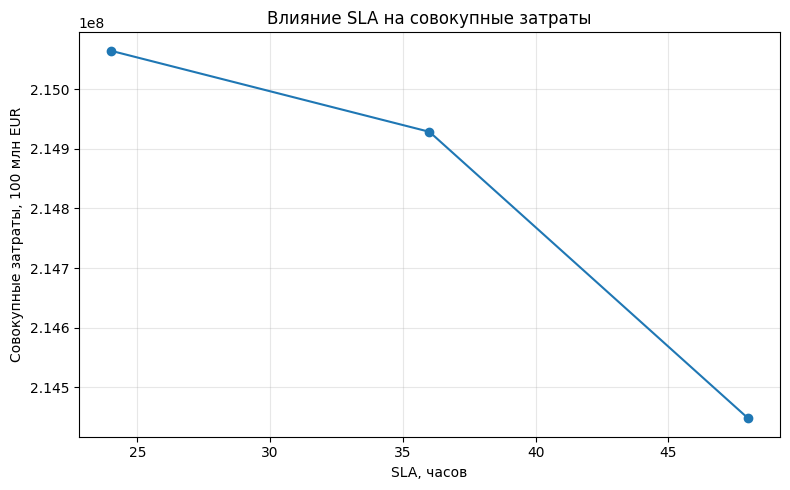

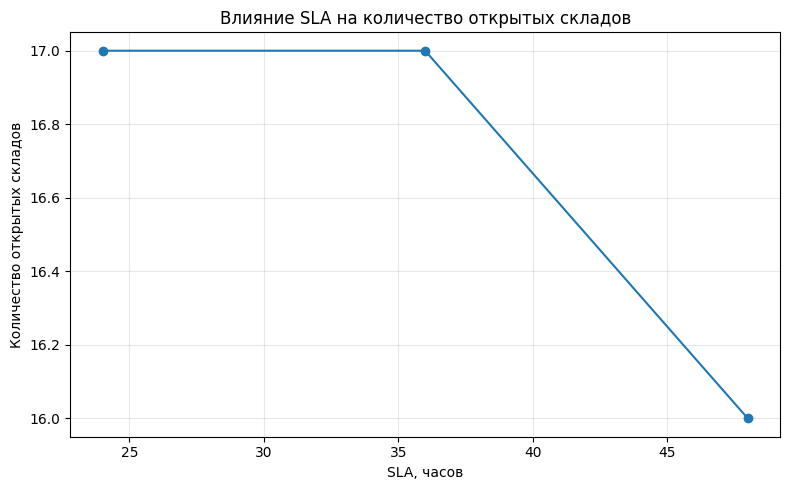

In [9]:
# Визуализация SLA-сценариев

import os
import pandas as pd
import matplotlib.pyplot as plt

# чтобы поправить формат больших чисел pandas
pd.options.display.float_format = "{:,.2f}".format

# форматирование осей matplotlib:
def format_number(x, pos):
    return f"{x:,.0f}".replace(",", " ")

def format_axis_plain(ax):
    ax.yaxis.set_major_formatter(FuncFormatter(format_number))
    ax.xaxis.set_major_formatter(FuncFormatter(format_number))

# файл, который создает AMPL-блок SLA
path = "scenario_sla_results.csv"
sla_df = pd.read_csv(path)

# приведение числовых колонок
num_cols = [
    "hours",
    "demand_factor",
    "rent_multiplier",
    "total_cost",
    "open_wh",
    "total_demand_t",
    "avg_time_h",
    "max_time_h"
]

for col in num_cols:
    if col in sla_df.columns:
        sla_df[col] = pd.to_numeric(sla_df[col], errors="coerce")

sla_df = sla_df.sort_values("hours")

display(sla_df)


# 1. Стоимость vs SLA

plt.figure(figsize=(8, 5))
plt.plot(
    sla_df["hours"],
    sla_df["total_cost"],
    marker="o"
)

plt.title("Влияние SLA на совокупные затраты")
plt.xlabel("SLA, часов")
plt.ylabel("Совокупные затраты, 100 млн EUR")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# 2. Количество открытых складов vs SLA

plt.figure(figsize=(8, 5))
plt.plot(
    sla_df["hours"],
    sla_df["open_wh"],
    marker="o"
)

plt.title("Влияние SLA на количество открытых складов")
plt.xlabel("SLA, часов")
plt.ylabel("Количество открытых складов")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



## Сценарий 2: изменение спроса

Проверяется, как рост или снижение спроса влияет на:
- совокупные затраты;
- количество открытых складов;
- суммарный объем перевозок;
- среднее и максимальное время доставки.

In [10]:
%%ampl_eval

option solver "highs";
option solver_msg 0;
option highs_options "time_limit=300 mip_rel_gap=0.01";

# подготовка таблицы вывода
printf "\n=== DEMAND SCENARIOS ===\n";
printf "Scenario\tHours\tDemandFactor\tRentMultiplier\tTotalCost\tOpenWH\tDemand_t\tAvgTime\tMaxTime\n";

printf "scenario,hours,demand_factor,rent_multiplier,total_cost,open_wh,total_demand_t,avg_time_h,max_time_h\n" > "scenario_demand_results.csv";

# перебор всех активных сценариев спроса
for {s in S: scenario_active[s] = 1 and scenario_group[s] = "demand"} {

    # параметры сценария
    let hours := scenario_hours[s];
    let demand_factor := scenario_demand_factor[s];
    let fixed_multiplier := scenario_rent_multiplier[s];

    solve; # запуск оптимизации

    # расчет показателей
    printf "%s\t%.0f\t%.3f\t\t%.3f\t\t%12.2f\t%.0f\t%.3f\t%.3f\t%.3f\n",
        s,
        hours,
        demand_factor,
        fixed_multiplier,
        TotalCost,
        sum {w in W} Open[w],
        sum {c in C} demand[c] / 1000,
        (
            sum {w in W, c in C}
                (dist[w,c] / avg_speed) * Flow[w,c]
        )
        /
        (
            sum {c in C} demand[c]
        ),
        max {w in W, c in C: Flow[w,c] > 0.000001}
            (dist[w,c] / avg_speed);

    # сохранение результатов в csv
    printf "%s,%.0f,%.3f,%.3f,%.2f,%.0f,%.3f,%.3f,%.3f\n",
        s,
        hours,
        demand_factor,
        fixed_multiplier,
        TotalCost,
        sum {w in W} Open[w],
        sum {c in C} demand[c] / 1000,
        (
            sum {w in W, c in C}
                (dist[w,c] / avg_speed) * Flow[w,c]
        )
        /
        (
            sum {c in C} demand[c]
        ),
        max {w in W, c in C: Flow[w,c] > 0.000001}
            (dist[w,c] / avg_speed)
        >> "scenario_demand_results.csv";
}

# восстановление базовых показателей
let hours := 36;
let demand_factor := 1;
let fixed_multiplier := 1;

printf "\nDemand scenarios saved to scenario_demand_results.csv\n";


=== DEMAND SCENARIOS ===
Scenario	Hours	DemandFactor	RentMultiplier	TotalCost	OpenWH	Demand_t	AvgTime	MaxTime
HiGHS 1.14.0:   lim:time = 300
  mip:gap = 0.01
demand_088	36	0.880		1.000		188340893.24	17	578294.816	5.090	33.664
HiGHS 1.14.0:   lim:time = 300
  mip:gap = 0.01
demand_092	36	0.920		1.000		197199193.70	17	604580.944	5.302	33.664
HiGHS 1.14.0:   lim:time = 300
  mip:gap = 0.01
demand_105	36	1.050		1.000		226435082.13	18	690010.860	5.845	35.113
HiGHS 1.14.0:   lim:time = 300
  mip:gap = 0.01
demand_112	36	1.120		1.000		242480472.92	18	736011.584	5.228	35.113

Demand scenarios saved to scenario_demand_results.csv


#### Визуализация результатов спроса
Графики показывают, что затраты растут почти линейно с объёмом спроса, а при росте более чем на 5% открывается дополнительный склад. Сеть устойчива к колебаниям спроса в диапазоне +-12%.

,scenario,hours,demand_factor,rent_multiplier,total_cost,open_wh,total_demand_t,avg_time_h,max_time_h
0,demand_088,36,0.88,1.00,"188,340,893.24",17,"578,294.82",5.09,33.66
1,demand_092,36,0.92,1.00,"197,199,193.70",17,"604,580.94",5.30,33.66
2,demand_105,36,1.05,1.00,"226,435,082.13",18,"690,010.86",5.84,35.11
3,demand_112,36,1.12,1.00,"242,480,472.92",18,"736,011.58",5.23,35.11


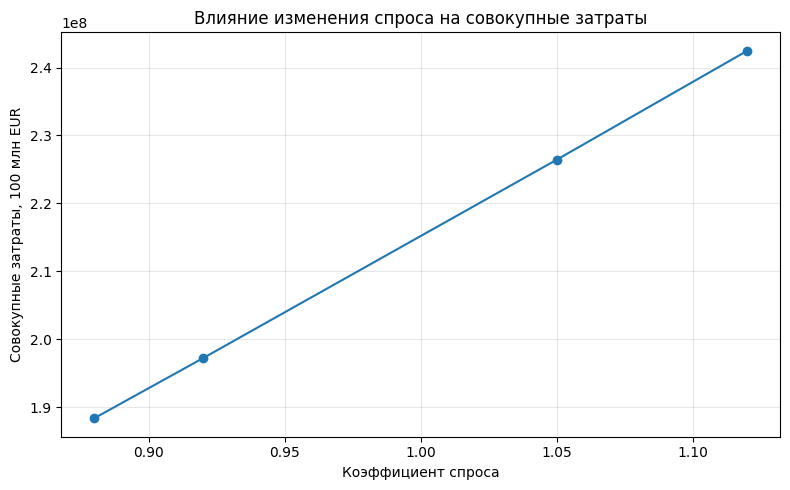

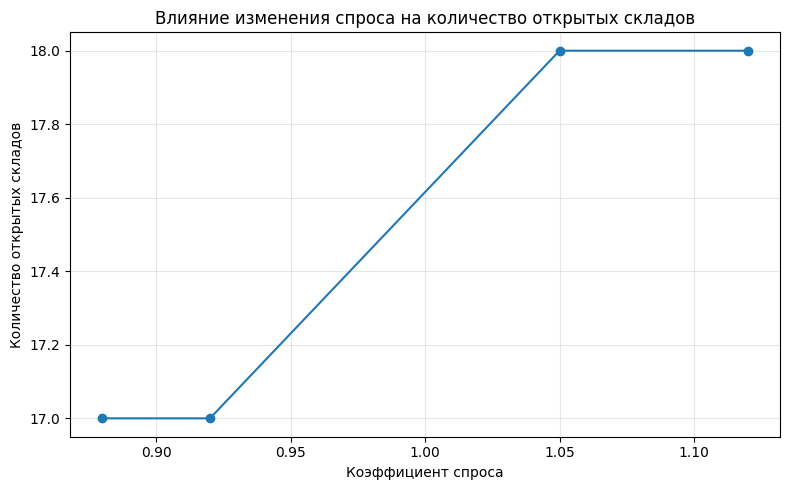

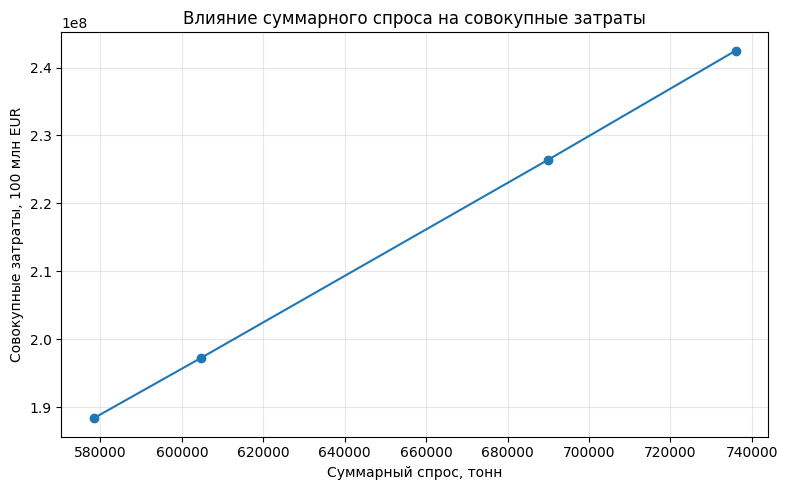

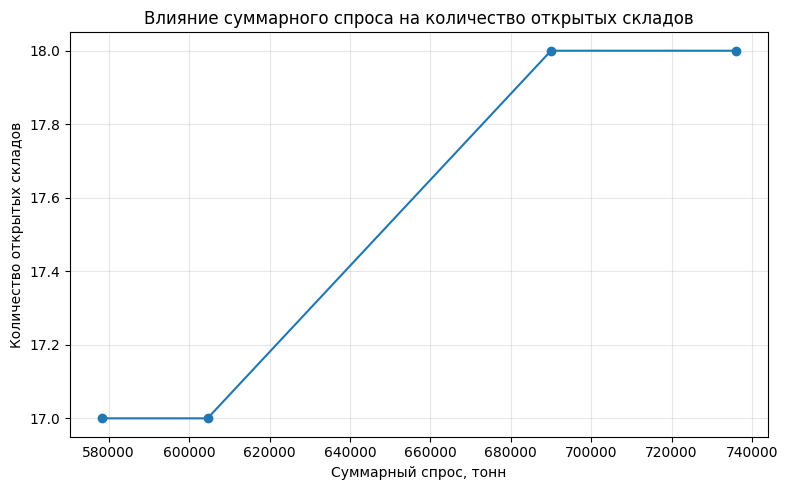

In [11]:

# Визуализация сценариев спроса

import os
import pandas as pd
import matplotlib.pyplot as plt

# чтобы поправить формат больших чисел pandas
pd.options.display.float_format = "{:,.2f}".format

# форматирование осей matplotlib:
def format_number(x, pos):
    return f"{x:,.0f}".replace(",", " ")

def format_axis_plain(ax):
    ax.yaxis.set_major_formatter(FuncFormatter(format_number))
    ax.xaxis.set_major_formatter(FuncFormatter(format_number))

# файл, который создает AMPL-блок demand
path = "scenario_demand_results.csv"

demand_df = pd.read_csv(path)

# приведение числовых колонок
num_cols = [
    "hours",
    "demand_factor",
    "rent_multiplier",
    "total_cost",
    "open_wh",
    "total_demand_t",
    "avg_time_h",
    "max_time_h"
]

for col in num_cols:
    if col in demand_df.columns:
        demand_df[col] = pd.to_numeric(demand_df[col], errors="coerce")

demand_df = demand_df.sort_values("demand_factor")

display(demand_df)


# 1. Стоимость vs коэффициент спроса

plt.figure(figsize=(8, 5))
plt.plot(
    demand_df["demand_factor"],
    demand_df["total_cost"],
    marker="o"
)

plt.title("Влияние изменения спроса на совокупные затраты")
plt.xlabel("Коэффициент спроса")
plt.ylabel("Совокупные затраты, 100 млн EUR")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# 2. Количество открытых складов vs коэффициент спроса

plt.figure(figsize=(8, 5))
plt.plot(
    demand_df["demand_factor"],
    demand_df["open_wh"],
    marker="o"
)

plt.title("Влияние изменения спроса на количество открытых складов")
plt.xlabel("Коэффициент спроса")
plt.ylabel("Количество открытых складов")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# 3. Стоимость vs суммарный спрос

plt.figure(figsize=(8, 5))
plt.plot(
    demand_df["total_demand_t"],
    demand_df["total_cost"],
    marker="o"
)

plt.title("Влияние суммарного спроса на совокупные затраты")
plt.xlabel("Суммарный спрос, тонн")
plt.ylabel("Совокупные затраты, 100 млн EUR")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# 4. Количество открытых складов vs суммарный спрос

plt.figure(figsize=(8, 5))
plt.plot(
    demand_df["total_demand_t"],
    demand_df["open_wh"],
    marker="o"
)

plt.title("Влияние суммарного спроса на количество открытых складов")
plt.xlabel("Суммарный спрос, тонн")
plt.ylabel("Количество открытых складов")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()




## Сценарий 3: изменение арендных ставок

Проверяется чувствительность решения к изменению складских арендных ставок.  
Этот сценарий показывает, насколько структура сети зависит от стоимости складской инфраструктуры.

In [12]:
%%ampl_eval

option solver "highs";
option solver_msg 0;
option highs_options "time_limit=300 mip_rel_gap=0.01";

# подготовка таблицы вывода
printf "\n=== RENT SCENARIOS ===\n";
printf "Scenario\tHours\tDemandFactor\tRentMultiplier\tTotalCost\tOpenWH\tDemand_t\tAvgTime\tMaxTime\n";

printf "scenario,hours,demand_factor,rent_multiplier,total_cost,open_wh,total_demand_t,avg_time_h,max_time_h\n" > "scenario_rent_results.csv";

# перебор всех активных сценариев аренды
for {s in S: scenario_active[s] = 1 and scenario_group[s] = "rent"} {

    # параметры текущего сценария
    let hours := scenario_hours[s];
    let demand_factor := scenario_demand_factor[s];
    let fixed_multiplier := scenario_rent_multiplier[s];

    solve; # запуск оптимизации

    # расчет показателей
    printf "%s\t%.0f\t%.3f\t\t%.3f\t\t%12.2f\t%.0f\t%.3f\t%.3f\t%.3f\n",
        s,
        hours,
        demand_factor,
        fixed_multiplier,
        TotalCost,
        sum {w in W} Open[w],
        sum {c in C} demand[c] / 1000,
        (
            sum {w in W, c in C}
                (dist[w,c] / avg_speed) * Flow[w,c]
        )
        /
        (
            sum {c in C} demand[c]
        ),
        max {w in W, c in C: Flow[w,c] > 0.000001}
            (dist[w,c] / avg_speed);

    # сохранение результатов в csv
    printf "%s,%.0f,%.3f,%.3f,%.2f,%.0f,%.3f,%.3f,%.3f\n",
        s,
        hours,
        demand_factor,
        fixed_multiplier,
        TotalCost,
        sum {w in W} Open[w],
        sum {c in C} demand[c] / 1000,
        (
            sum {w in W, c in C}
                (dist[w,c] / avg_speed) * Flow[w,c]
        )
        /
        (
            sum {c in C} demand[c]
        ),
        max {w in W, c in C: Flow[w,c] > 0.000001}
            (dist[w,c] / avg_speed)
        >> "scenario_rent_results.csv";
}

# восстановление базовых показателей
let hours := 36;
let demand_factor := 1;
let fixed_multiplier := 1;

printf "\nRent scenarios saved to scenario_rent_results.csv\n";


=== RENT SCENARIOS ===
Scenario	Hours	DemandFactor	RentMultiplier	TotalCost	OpenWH	Demand_t	AvgTime	MaxTime
HiGHS 1.14.0:   lim:time = 300
  mip:gap = 0.01
rent_085	36	1.000		0.850		213100132.91	17	657153.200	5.184	33.664
HiGHS 1.14.0:   lim:time = 300
  mip:gap = 0.01
rent_091	36	1.000		0.910		213843438.54	17	657153.200	5.883	33.664
HiGHS 1.14.0:   lim:time = 300
  mip:gap = 0.01
rent_097	36	1.000		0.970		214567454.30	17	657153.200	5.690	33.664
HiGHS 1.14.0:   lim:time = 300
  mip:gap = 0.01
rent_103	36	1.000		1.030		215289222.88	17	657153.200	5.690	33.664
HiGHS 1.14.0:   lim:time = 300
  mip:gap = 0.01
rent_109	36	1.000		1.090		216010991.46	17	657153.200	5.690	33.664
HiGHS 1.14.0:   lim:time = 300
  mip:gap = 0.01
rent_115	36	1.000		1.150		216732760.04	17	657153.200	5.690	33.664

Rent scenarios saved to scenario_rent_results.csv


#### Визуализация результатов аренды
Графики показывают, что структура сети (количество складов) не меняется при изменении арендных ставок, а затраты растут линейно. При низкой аренде можно выбрать более выгодные локации складов.

,scenario,hours,demand_factor,rent_multiplier,total_cost,open_wh,total_demand_t,avg_time_h,max_time_h
0,rent_085,36,1.00,0.85,"213,100,132.91",17,"657,153.20",5.18,33.66
1,rent_091,36,1.00,0.91,"213,843,438.54",17,"657,153.20",5.88,33.66
2,rent_097,36,1.00,0.97,"214,567,454.30",17,"657,153.20",5.69,33.66
3,rent_103,36,1.00,1.03,"215,289,222.88",17,"657,153.20",5.69,33.66
4,rent_109,36,1.00,1.09,"216,010,991.46",17,"657,153.20",5.69,33.66
5,rent_115,36,1.00,1.15,"216,732,760.04",17,"657,153.20",5.69,33.66


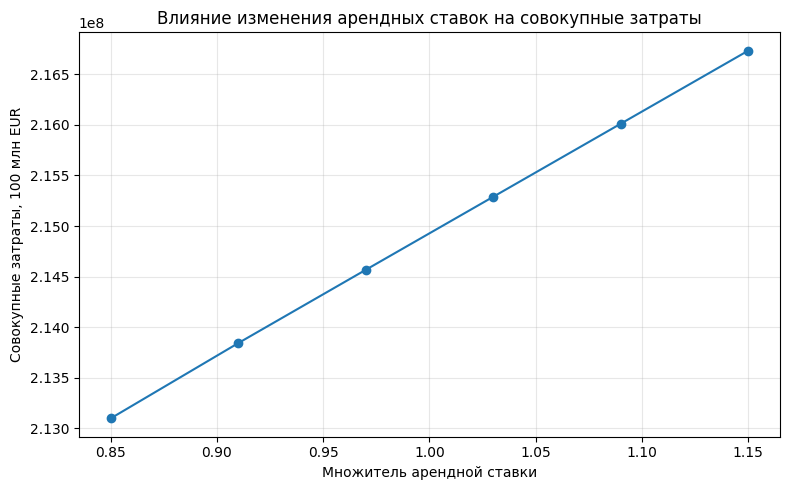

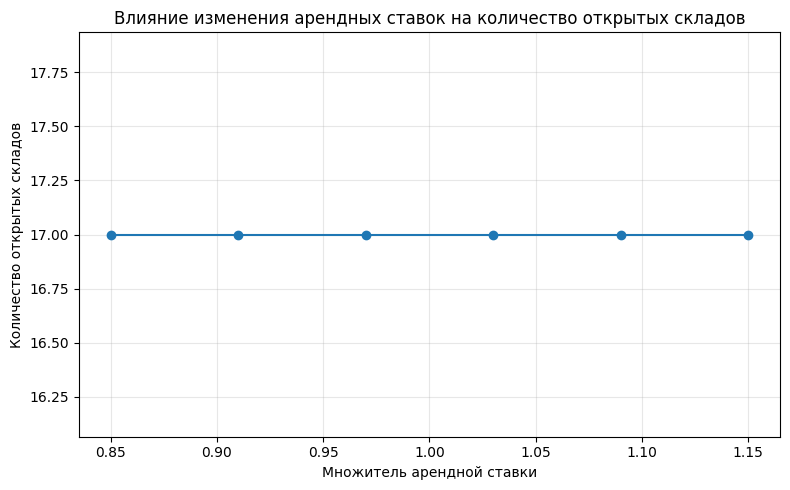

In [13]:

# Визуализация сценариев аренды

import os
import pandas as pd
import matplotlib.pyplot as plt

# чтобы поправить формат больших чисел pandas
pd.options.display.float_format = "{:,.2f}".format

# форматирование осей matplotlib:
def format_number(x, pos):
    return f"{x:,.0f}".replace(",", " ")

def format_axis_plain(ax):
    ax.yaxis.set_major_formatter(FuncFormatter(format_number))
    ax.xaxis.set_major_formatter(FuncFormatter(format_number))

# файл, который создает AMPL-блок rent
path = "scenario_rent_results.csv"

rent_df = pd.read_csv(path)

# приведение числовых колонок
num_cols = [
    "hours",
    "demand_factor",
    "rent_multiplier",
    "total_cost",
    "open_wh",
    "total_demand_t",
    "avg_time_h",
    "max_time_h"
]

for col in num_cols:
    if col in rent_df.columns:
        rent_df[col] = pd.to_numeric(rent_df[col], errors="coerce")

rent_df = rent_df.sort_values("rent_multiplier")

display(rent_df)


# 1. Стоимость vs множитель аренды

plt.figure(figsize=(8, 5))
plt.plot(
    rent_df["rent_multiplier"],
    rent_df["total_cost"],
    marker="o"
)

plt.title("Влияние изменения арендных ставок на совокупные затраты")
plt.xlabel("Множитель арендной ставки")
plt.ylabel("Совокупные затраты, 100 млн EUR")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# 2. Количество открытых складов vs множитель аренды

plt.figure(figsize=(8, 5))
plt.plot(
    rent_df["rent_multiplier"],
    rent_df["open_wh"],
    marker="o"
)

plt.title("Влияние изменения арендных ставок на количество открытых складов")
plt.xlabel("Множитель арендной ставки")
plt.ylabel("Количество открытых складов")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



# **Многокритериальный анализ: стоимость vs время доставки**

В этом разделе исследуется компромисс между двумя критериями:
- минимизацией совокупных логистических затрат;
- сокращением максимального времени доставки.

Для построения границы Парето используется изменение SLA-ограничения. Для каждой точки модель минимизирует затраты при заданном ограничении на время доставки.

In [14]:
%%ampl_eval

option solver "highs";
option solver_msg 0;
option highs_options "time_limit=300 mip_rel_gap=0.01";

# подготовка таблицы вывода
printf "\n=== PARETO FRONTIER: COST VS DELIVERY TIME ===\n";
printf "Scenario\tSLA_hours\tTotalCost\tOpenWH\tDemand_t\tAvgTime\tMaxTime\n";

printf "scenario,sla_hours,total_cost,open_wh,total_demand_t,avg_time_h,max_time_h\n" > "pareto_results.csv";

# цикл по выбранному набору стратегических анализов
for {s in S: scenario_active[s] = 1 and scenario_group[s] = "par"} {

    let hours := scenario_hours[s];

    solve;  # решение

    # вывод результатов
    printf "%s\t%.0f\t\t%12.2f\t%.0f\t%.3f\t%.3f\t%.3f\n",
        s,
        hours,
        TotalCost,
        sum {w in W} Open[w],
        sum {c in C} demand[c] / 1000,
        (
            sum {w in W, c in C}
                (dist[w,c] / avg_speed) * Flow[w,c]
        )
        /
        (
            sum {c in C} demand[c]
        ),
        max {w in W, c in C: Flow[w,c] > 0.000001}
            (dist[w,c] / avg_speed);

    # запись в csv
    printf "%s,%.0f,%.2f,%.0f,%.3f,%.3f,%.3f\n",
        s,
        hours,
        TotalCost,
        sum {w in W} Open[w],
        sum {c in C} demand[c] / 1000,
        (
            sum {w in W, c in C}
                (dist[w,c] / avg_speed) * Flow[w,c]
        )
        /
        (
            sum {c in C} demand[c]
        ),
        max {w in W, c in C: Flow[w,c] > 0.000001}
            (dist[w,c] / avg_speed)
        >> "pareto_results.csv";
}

# сброс до базовых показателей
let hours := 36;
let demand_factor := 1;
let fixed_multiplier := 1;

printf "\nPareto results saved to pareto_results.csv\n";


=== PARETO FRONTIER: COST VS DELIVERY TIME ===
Scenario	SLA_hours	TotalCost	OpenWH	Demand_t	AvgTime	MaxTime
HiGHS 1.14.0:   lim:time = 300
  mip:gap = 0.01
par_24	24		215064247.04	17	657153.200	4.758	21.886
HiGHS 1.14.0:   lim:time = 300
  mip:gap = 0.01
par_30	30		215031189.87	17	657153.200	5.457	27.010
HiGHS 1.14.0:   lim:time = 300
  mip:gap = 0.01
par_36	36		214928338.59	17	657153.200	5.690	33.664
HiGHS 1.14.0:   lim:time = 300
  mip:gap = 0.01
par_42	42		214595158.62	16	657153.200	6.541	39.177
HiGHS 1.14.0:   lim:time = 300
  mip:gap = 0.01
par_48	48		214448199.08	16	657153.200	6.452	43.595

Pareto results saved to pareto_results.csv


,scenario,sla_hours,total_cost,open_wh,total_demand_t,avg_time_h,max_time_h
0,par_24,24,"215,064,247.04",17,"657,153.20",4.76,21.89
1,par_30,30,"215,031,189.87",17,"657,153.20",5.46,27.01
2,par_36,36,"214,928,338.59",17,"657,153.20",5.69,33.66
3,par_42,42,"214,595,158.62",16,"657,153.20",6.54,39.18
4,par_48,48,"214,448,199.08",16,"657,153.20",6.45,43.59


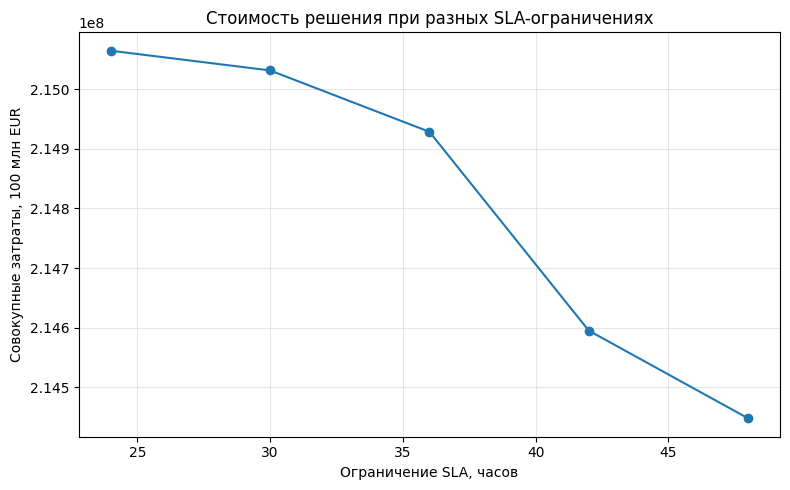

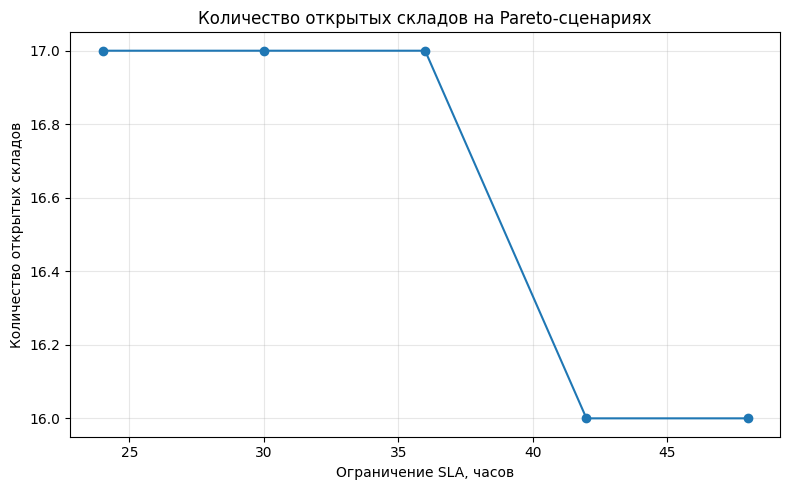

In [15]:

# Визуализация Pareto

import os
import pandas as pd
import matplotlib.pyplot as plt

# чтобы поправить формат больших чисел pandas
pd.options.display.float_format = "{:,.2f}".format

# форматирование осей matplotlib:
def format_number(x, pos):
    return f"{x:,.0f}".replace(",", " ")

def format_axis_plain(ax):
    ax.yaxis.set_major_formatter(FuncFormatter(format_number))
    ax.xaxis.set_major_formatter(FuncFormatter(format_number))


# файл, который создает AMPL-блок Pareto
path = "pareto_results.csv"

pareto_df = pd.read_csv(path)

# приведение числовых колонок
num_cols = [
    "sla_hours",
    "total_cost",
    "open_wh",
    "total_demand_t",
    "avg_time_h",
    "max_time_h"
]

for col in num_cols:
    if col in pareto_df.columns:
        pareto_df[col] = pd.to_numeric(pareto_df[col], errors="coerce")

pareto_df = pareto_df.sort_values("sla_hours")

display(pareto_df)


# 1. Стоимость vs SLA-ограничение

plt.figure(figsize=(8, 5))
plt.plot(
    pareto_df["sla_hours"],
    pareto_df["total_cost"],
    marker="o"
)

plt.title("Стоимость решения при разных SLA-ограничениях")
plt.xlabel("Ограничение SLA, часов")
plt.ylabel("Совокупные затраты, 100 млн EUR")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# 2. Количество открытых складов vs SLA-ограничение

plt.figure(figsize=(8, 5))
plt.plot(
    pareto_df["sla_hours"],
    pareto_df["open_wh"],
    marker="o"
)

plt.title("Количество открытых складов на Pareto-сценариях")
plt.xlabel("Ограничение SLA, часов")
plt.ylabel("Количество открытых складов")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()




**Выводы по Парето-границе:**  
- Ужесточение SLA с 48 до 24 часов увеличивает затраты всего на ~0,3%, но значительно улучшает максимальное время (с 43,6 до 21,9 ч).  
- Компромисс наиболее крут на участке 24–30 часов, где каждый дополнительный час времени даёт заметное снижение затрат.  
- Рекомендуемое решение для бизнеса — SLA = 36 часов, как разумный баланс между сервисом и экономикой.

# Описание применения генеративных моделей

В ходе проекта использовались ChatGPT и DeepSeek для вспомогательных задач:

- **Проверка AMPL-модели**: выявление ошибок в ограничениях, переменных, единицах измерения и логике сценариев.
- **Работа с данными**: помощь в структурировании данных и проверке соответствия параметров модели Excel-файлу.
- **Визуализация**: подготовка шаблонов Python-кода для графиков и интерактивной карты (адаптированы под структуру проекта).
- **Выгрузка результатов**: подготовка кода для экспорта данных в табличный формат.

**Модели:** ChatGPT (GPT-5.5 Thinking), DeepSeek (веб-интерфейс).

**Оценка эффективности:** ИИ ускорил техническую часть работы (поиск ошибок, проверка кода, подготовка визуализаций). Однако ИИ **не использовался** для интерпретации результатов, написания выводов или замены расчётов — все итоговые решения, интерпретации и рекомендации подготовлены авторами самостоятельно. Ответственность за модель и результаты несёт проектная команда.